# Exploratory Data Analysis - Formula 1 Dataset

Este notebook explora a componente de EDA (Análise Exploratória de Dados) para preparação e análise de um conjunto de dados provenientes de um dataset de Fórmula 1, com o objetivo de serem aplicados num modelo de clustering de aprendizagem não supervisionada

Trata-se de um conjunto de dados do campeonato de Fórmula 1 que contém registos desde 1950 até 2024, disponível em: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020. Este dataset contém todas as informações da Fórmula 1, incluindo corridas, pilotos, construtores (equipas), qualificações, circuitos, tempos das voltas, pit stops e campeonatos.

### O que é formula 1?
A Fórmula 1 é uma competição internacional de automobilismo composta por uma época anual de corridas, chamadas Grandes Prémios, disputadas por equipas que constroem os seus próprios carros de acordo com regulamentos técnicos definidos pela FIA. Cada prova atribui pontos aos pilotos e às equipas, que contam para dois campeonatos separados: o de Pilotos e o de Construtores. Os carros utilizados são monolugares de elevada performance, concebidos para maximizar velocidade, aerodinâmica e eficiência.

### O que contêm o dataset
O dataset é composto por vários ficheiros csv (circuitos, corridas, resultados, lap times, pit stops, etc.) Cada registo pode contem IDs para ligação dos dados para um maior contexto. Neste notebook, focamos na utilização principal de quatro ficheiros:
- ``` results.csv```: Contém os resultados das corridas de todos os pilotos que participaram.
- ``` sprints_results.csv ```: O mesmo formato que os resultados, mas para as corridas sprint.
- ``` qualifiying.csv  ```: O resultado das qualificações que decide a posição inicial nas corridas.
- ```drivers.csv```: Informações gerais e demográficas dos pilotos.

Podemos encontrar dados como:
- ```grid```: Posição inicial do piloto.
- ```position```: Posição que o piloto terminou a corrida.
- ```points```: Quantos pontos o piloto ganhou na corrida.
- ```laps```: Voltas que o piloto realizou.
- ```milliseconds```: O tempo que o piloto demorou a terminar a corrida (em milissegundos).
- ```fastestLap```: Número da volta mais rápida do piloto.
- ```fastestLapTime```: Tempo da volta mais rápida.
- ```fastestLapSpeed```: Velocidade máxima do piloto na sua volta mais rápida.
- ```statusId```: Categoria do estado final do piloto: (Ex: 1. Terminou Normalmente, 4. Não terminou a corrida, etc...).
- ```q1, q2, q3```: Tempos das sessões de qualificação.

Com estes dados, podemos obter uma visão inicial do desempenho histórico dos pilotos.

### Objetivo deste Notebook e do Dataset
O objetivo final é aplicar técnicas de clustering (como o K-Means) para encontrar padrões de interesse útil, previamente desconhecidos, ligados ao desempenho e perfil dos pilotos. Para tal, este notebook utiliza técnicas de EDA para selecionar, limpar, filtrar e explorar a viabilidade dos dados. Em outras palavras, este processo serve para processar e garantir que os dados estão estruturados e minimamente concebidos para alimentar o modelo KMeans.

### O que podemos encontrar neste notebook
- **Importação dos Dados:** Carregamento dados relevantes para análise.
- **Descrição e Seleção das Variáveis:** Verificação do conteúdo de cada tabela, tipos de dados e seleção de features de interesse.
- **Conversão de Tipo de dados:** Tratamento de dados nulos e conversão de tipos (ex: objetos para int ou float).
- **Análise Univariada:** Análise individual de cada variável para entender a sua distribuição e detetar outliers.
- **Análise Bivariada:** Visualizações e estatísticas resumidas para avaliar a relação (correlação) entre variáveis do conjunto de dados.
- **Engenharia de Features:** Transformação e criação de novas variáveis a partir dos dados existentes para extrair mais informação e quando necessário, reduzir a dimensionalidade ou complexidade para o modelo.


## Importar Bibliotecas

Neste segmento, são importadas as bibliotecas e modulos Python necessários para este Notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os

## Carregar os Dados

Nesta parte do notebook são definidos os caminhos e carregados os ficheiros. De seguida, é realizada uma filtragem inicial para manter apenas os dados de 2022 a 2024. Esta janela temporal foi escolhida devido à alteração nos regulamentos da Fórmula 1 em 2022, que mudou significativamente a aerodinâmica e o comportamento dos carros.

In [2]:
races_path = 'data/f1_dataset/races.csv'
results_path = 'data/f1_dataset/results.csv'
drivers_path = 'data/f1_dataset/drivers.csv'
constructors_path = 'data/f1_dataset/constructors.csv'
sprints_path = 'data/f1_dataset/sprint_results.csv'
qualifying_path = 'data/f1_dataset/qualifying.csv'
driver_standings_path = 'data/f1_dataset/driver_standings.csv'
constructor_standings_path = 'data/f1_dataset/constructor_standings.csv'
lap_times_path = 'data/f1_dataset/lap_times.csv'
pit_stops_path = 'data/f1_dataset/pit_stops.csv'
circuits_path = 'data/f1_dataset/circuits.csv'

# Load races dataframe
races_df = pd.read_csv(races_path)
# Filter races for years 2022 to present
races_2024 = races_df[races_df['year'] >= 2022]
races_2024.reset_index(drop=True, inplace=True)
# Get the list of race IDs for the filtered period
race_ids = races_2024['raceId'].unique()

# Load results dataframe
results_df = pd.read_csv(results_path)
# Filter results based on the race IDs
results_2024 = results_df[results_df['raceId'].isin(race_ids)]
results_2024.reset_index(drop=True, inplace=True)
#Load drivers and constructors for 2022-Present
drivers_2024 = results_2024['driverId'].unique()
constructors_2024 = results_2024['constructorId'].unique()

#Load sprints and qualifying for 2022-Present
sprints_df = pd.read_csv(sprints_path)
qualifying_df = pd.read_csv(qualifying_path)
sprints_2024 = sprints_df[sprints_df['raceId'].isin(race_ids)]
sprints_2024.reset_index(drop=True, inplace=True)
qualifying_2024 = qualifying_df[qualifying_df['raceId'].isin(race_ids)]
qualifying_2024.reset_index(drop=True, inplace=True)

lap_times_df = pd.read_csv(lap_times_path)
lap_times_2024 = lap_times_df[lap_times_df['raceId'].isin(race_ids)]
lap_times_2024.reset_index(drop=True, inplace=True)

pit_stops_df = pd.read_csv(pit_stops_path)
pit_stops_2024 = pit_stops_df[pit_stops_df['raceId'].isin(race_ids)]
pit_stops_2024.reset_index(drop=True, inplace=True)

# Load additional context dataframes (no filtering needed usually)
constructors_df = pd.read_csv(constructors_path)
constructors_2024_df = constructors_df[constructors_df['constructorId'].isin(constructors_2024)]
constructors_2024_df.reset_index(drop=True, inplace=True)

circuits_df = pd.read_csv(circuits_path)
circuits_2024_df = circuits_df[circuits_df['circuitId'].isin(races_2024['circuitId'].unique())]
circuits_2024_df.reset_index(drop=True, inplace=True)

drivers_df = pd.read_csv(drivers_path)
drivers_2024_df = drivers_df[drivers_df['driverId'].isin(drivers_2024)]
drivers_2024_df.reset_index(drop=True, inplace=True)


# Display the first few rows and shapes to verify
print("Races (2022-2024) Shape:", races_2024.shape)
print("Results (2022-2024) Shape:", results_2024.shape)
print("Sprints Results (2022-2024) Shape:", sprints_2024.shape)
print("Qualifying (2022-2024) Shape:", qualifying_2024.shape)
print("Driver (2022-2024) Shape:", drivers_2024.shape)
print("Constructor (2022-2024) Shape:", constructors_2024.shape)
print("Lap Times (2022-2024) Shape:", lap_times_2024.shape)
print("Pit Stops (2022-2024) Shape:", pit_stops_2024.shape)
print("Circuits (2022-2024) Shape:", circuits_2024_df.shape)
print("Constructor (2022-2024) Shape:", constructors_2024_df.shape)

Races (2022-2024) Shape: (68, 18)
Results (2022-2024) Shape: (1359, 18)
Sprints Results (2022-2024) Shape: (300, 16)
Qualifying (2022-2024) Shape: (1359, 9)
Driver (2022-2024) Shape: (28,)
Constructor (2022-2024) Shape: (12,)
Lap Times (2022-2024) Shape: (74489, 6)
Pit Stops (2022-2024) Shape: (2542, 7)
Circuits (2022-2024) Shape: (25, 9)
Constructor (2022-2024) Shape: (12, 5)


## Descrição e Seleção das Variáveis

São selecionados os conjuntos de dados e é feita uma análise inicial dos dados onde podemos verificar o tipo de variáveis e quais colunas contêm como a quantidade de registos.


In [3]:
results_2024.info()
sprints_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         1359 non-null   int64  
 1   raceId           1359 non-null   int64  
 2   driverId         1359 non-null   int64  
 3   constructorId    1359 non-null   int64  
 4   number           1359 non-null   object 
 5   grid             1359 non-null   int64  
 6   position         1359 non-null   object 
 7   positionText     1359 non-null   object 
 8   positionOrder    1359 non-null   int64  
 9   points           1359 non-null   float64
 10  laps             1359 non-null   int64  
 11  time             1359 non-null   object 
 12  milliseconds     1359 non-null   object 
 13  fastestLap       1359 non-null   object 
 14  rank             1359 non-null   object 
 15  fastestLapTime   1359 non-null   object 
 16  fastestLapSpeed  1359 non-null   object 
 17  statusId      

In [4]:
qualifying_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qualifyId      1359 non-null   int64 
 1   raceId         1359 non-null   int64 
 2   driverId       1359 non-null   int64 
 3   constructorId  1359 non-null   int64 
 4   number         1359 non-null   int64 
 5   position       1359 non-null   int64 
 6   q1             1359 non-null   object
 7   q2             1337 non-null   object
 8   q3             1313 non-null   object
dtypes: int64(6), object(3)
memory usage: 95.7+ KB


In [5]:
circuits_2024_df.info()
circuits_2024_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   25 non-null     int64  
 1   circuitRef  25 non-null     object 
 2   name        25 non-null     object 
 3   location    25 non-null     object 
 4   country     25 non-null     object 
 5   lat         25 non-null     float64
 6   lng         25 non-null     float64
 7   alt         25 non-null     int64  
 8   url         25 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 1.9+ KB


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.0325,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
2,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.5700,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
3,6,monaco,Circuit de Monaco,Monte-Carlo,Monaco,43.7347,7.42056,7,http://en.wikipedia.org/wiki/Circuit_de_Monaco
4,7,villeneuve,Circuit Gilles Villeneuve,Montreal,Canada,45.5000,-73.52280,13,http://en.wikipedia.org/wiki/Circuit_Gilles_Vi...


In [6]:
constructors_2024_df.info()
constructors_2024_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   12 non-null     int64 
 1   constructorRef  12 non-null     object
 2   name            12 non-null     object
 3   nationality     12 non-null     object
 4   url             12 non-null     object
dtypes: int64(1), object(4)
memory usage: 612.0+ bytes


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
2,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari
3,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing
4,15,sauber,Sauber,Swiss,http://en.wikipedia.org/wiki/Sauber_Motorsport


In [7]:
races_2024.info()
races_2024.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       68 non-null     int64 
 1   year         68 non-null     int64 
 2   round        68 non-null     int64 
 3   circuitId    68 non-null     int64 
 4   name         68 non-null     object
 5   date         68 non-null     object
 6   time         68 non-null     object
 7   url          68 non-null     object
 8   fp1_date     68 non-null     object
 9   fp1_time     68 non-null     object
 10  fp2_date     68 non-null     object
 11  fp2_time     68 non-null     object
 12  fp3_date     68 non-null     object
 13  fp3_time     68 non-null     object
 14  quali_date   68 non-null     object
 15  quali_time   68 non-null     object
 16  sprint_date  68 non-null     object
 17  sprint_time  68 non-null     object
dtypes: int64(4), object(14)
memory usage: 9.7+ KB


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1074,2022,1,3,Bahrain Grand Prix,2022-03-20,15:00:00,http://en.wikipedia.org/wiki/2022_Bahrain_Gran...,2022-03-18,12:00:00,2022-03-18,15:00:00,2022-03-19,12:00:00,2022-03-19,15:00:00,\N,\N
1,1075,2022,2,77,Saudi Arabian Grand Prix,2022-03-27,17:00:00,http://en.wikipedia.org/wiki/2022_Saudi_Arabia...,2022-03-25,14:00:00,2022-03-25,17:00:00,2022-03-26,14:00:00,2022-03-26,17:00:00,\N,\N
2,1076,2022,3,1,Australian Grand Prix,2022-04-10,05:00:00,http://en.wikipedia.org/wiki/2022_Australian_G...,2022-04-08,03:00:00,2022-04-08,06:00:00,2022-04-09,03:00:00,2022-04-09,06:00:00,\N,\N
3,1077,2022,4,21,Emilia Romagna Grand Prix,2022-04-24,13:00:00,http://en.wikipedia.org/wiki/2022_Emilia_Romag...,2022-04-22,11:30:00,2022-04-23,10:30:00,\N,\N,2022-04-22,15:00:00,2022-04-23,14:30:00
4,1078,2022,5,79,Miami Grand Prix,2022-05-08,19:30:00,http://en.wikipedia.org/wiki/2022_Miami_Grand_...,2022-05-06,18:30:00,2022-05-06,21:30:00,2022-05-07,17:00:00,2022-05-07,20:00:00,\N,\N


In [8]:
drivers_2024_df.info()
drivers_2024_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     28 non-null     int64 
 1   driverRef    28 non-null     object
 2   number       28 non-null     object
 3   code         28 non-null     object
 4   forename     28 non-null     object
 5   surname      28 non-null     object
 6   dob          28 non-null     object
 7   nationality  28 non-null     object
 8   url          28 non-null     object
dtypes: int64(1), object(8)
memory usage: 2.1+ KB


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
2,20,vettel,5,VET,Sebastian,Vettel,1987-07-03,German,http://en.wikipedia.org/wiki/Sebastian_Vettel
3,842,gasly,10,GAS,Pierre,Gasly,1996-02-07,French,http://en.wikipedia.org/wiki/Pierre_Gasly
4,807,hulkenberg,27,HUL,Nico,Hülkenberg,1987-08-19,German,http://en.wikipedia.org/wiki/Nico_H%C3%BClkenberg


In [9]:
lap_times_2024.info()
lap_times_2024.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74489 entries, 0 to 74488
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        74489 non-null  int64 
 1   driverId      74489 non-null  int64 
 2   lap           74489 non-null  int64 
 3   position      74489 non-null  int64 
 4   time          74489 non-null  object
 5   milliseconds  74489 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 3.4+ MB


,raceId,driverId,lap,position,time,milliseconds
0,1074,844,1,1,1:39.070,99070
1,1074,844,2,1,1:37.853,97853
2,1074,844,3,1,1:38.272,98272
3,1074,844,4,1,1:38.414,98414
4,1074,844,5,1,1:38.471,98471


In [10]:
pit_stops_2024.info()
pit_stops_2024.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        2542 non-null   int64 
 1   driverId      2542 non-null   int64 
 2   stop          2542 non-null   int64 
 3   lap           2542 non-null   int64 
 4   time          2542 non-null   object
 5   duration      2542 non-null   object
 6   milliseconds  2542 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 139.1+ KB


,raceId,driverId,stop,lap,time,duration,milliseconds
0,1074,1,1,11,18:21:54,25.201,25201
1,1074,4,1,11,18:22:10,25.365,25365
2,1074,854,1,12,18:24:08,25.214,25214
3,1074,848,1,13,18:25:47,24.874,24874
4,1074,830,1,14,18:26:43,24.897,24897


Após a análise inicial dos dados de F1 de 2022 a 2024, podemos observar que os conjuntos de dados estão bem estruturados e contêm informações detalhadas sobre corridas, resultados, pilotos, construtores, tempos de volta e pit stops.

O proxímo passo é feita a seleção inicial das features que contêm informações relevantes para avaliar o desempenho dos pilotos.

In [11]:
results_features = ['driverId', 'raceId','constructorId', 'grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'session_type']
circuits_features = ['circuitId', 'circuitRef', 'alt']
constructors_features = ['constructorId', 'constructorRef']
races_features = ['raceId', 'circuitId']
driver_features = ['driverId', 'driverRef', 'nationality', 'dob']
qualifying_features = ['raceId','driverId', 'q1', 'q2', 'q3']

In [12]:
#Categorizar as sessões de corrida e sprint
results_df = results_2024.copy()
sprint_df = sprints_2024.copy()
results_df['session_type'] = 'race'
sprint_df['session_type'] = 'sprint'

#Combinação para um dataframe os resultados das corridas e sprints
combined_df = pd.concat([results_df, sprint_df], ignore_index=True)
combined_df

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,session_type
0,25406,1074,844,6,16,1,1,1,1,26.0,57,1:37:33.584,5853584,51,1,1:34.570,206.018,1,race
1,25407,1074,832,6,55,3,2,2,2,18.0,57,+5.598,5859182,52,3,1:35.740,203.501,1,race
2,25408,1074,1,131,44,5,3,3,3,15.0,57,+9.675,5863259,53,5,1:36.228,202.469,1,race
3,25409,1074,847,131,63,9,4,4,4,12.0,57,+11.211,5864795,56,6,1:36.302,202.313,1,race
4,25410,1074,825,210,20,7,5,5,5,10.0,57,+14.754,5868338,53,8,1:36.623,201.641,1,race
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,356,1143,859,215,30,10,16,16,16,0.0,19,+34.356,1657366,18,NaN,1:25.762,NaN,1,sprint
1655,357,1143,852,215,22,16,17,17,17,0.0,19,+35.102,1658112,17,NaN,1:25.838,NaN,1,sprint
1656,358,1143,861,3,43,0,18,18,18,0.0,19,+35.639,1658649,18,NaN,1:25.599,NaN,1,sprint
1657,359,1143,855,15,24,18,19,19,19,0.0,19,+1:11.436,1694446,19,NaN,1:25.051,NaN,1,sprint


Nesta secção é juntado todos os dados relevantes num só dataframe para facilitar a utilização dos dados:

In [13]:
con1 = pd.merge(combined_df[results_features], races_2024[races_features], on='raceId')
con2 = pd.merge(con1, drivers_2024_df[driver_features], on='driverId')
con3 = pd.merge(con2, constructors_df[constructors_features], on='constructorId')
con4 = pd.merge(con3, circuits_2024_df[circuits_features], on='circuitId')
con5 = pd.merge(con4, qualifying_2024[qualifying_features], on=['raceId', 'driverId'], how='left')
selected_df = con5.drop(['constructorId', 'circuitId', 'driverId'], axis=1) #Remove IDs desnecessários

In [14]:
selected_df.info()
selected_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   raceId           1659 non-null   int64  
 1   grid             1659 non-null   int64  
 2   positionOrder    1659 non-null   int64  
 3   points           1659 non-null   float64
 4   laps             1659 non-null   int64  
 5   milliseconds     1659 non-null   object 
 6   fastestLapTime   1659 non-null   object 
 7   fastestLapSpeed  1359 non-null   object 
 8   statusId         1659 non-null   int64  
 9   session_type     1659 non-null   object 
 10  driverRef        1659 non-null   object 
 11  nationality      1659 non-null   object 
 12  dob              1659 non-null   object 
 13  constructorRef   1659 non-null   object 
 14  circuitRef       1659 non-null   object 
 15  alt              1659 non-null   int64  
 16  q1               1659 non-null   object 
 17  q2            

,raceId,grid,positionOrder,points,laps,milliseconds,fastestLapTime,fastestLapSpeed,statusId,session_type,driverRef,nationality,dob,constructorRef,circuitRef,alt,q1,q2,q3
0,1074,1,1,26.0,57,5853584,1:34.570,206.018,1,race,leclerc,Monegasque,1997-10-16,ferrari,bahrain,7,1:31.471,1:30.932,1:30.558
1,1074,3,2,18.0,57,5859182,1:35.740,203.501,1,race,sainz,Spanish,1994-09-01,ferrari,bahrain,7,1:31.567,1:30.787,1:30.687
2,1074,5,3,15.0,57,5863259,1:36.228,202.469,1,race,hamilton,British,1985-01-07,mercedes,bahrain,7,1:32.285,1:31.048,1:31.238
3,1074,9,4,12.0,57,5864795,1:36.302,202.313,1,race,russell,British,1998-02-15,mercedes,bahrain,7,1:32.269,1:31.252,1:32.216
4,1074,7,5,10.0,57,5868338,1:36.623,201.641,1,race,kevin_magnussen,Danish,1992-10-05,haas,bahrain,7,1:31.955,1:31.461,1:31.808


In [15]:
selected_df.isna().sum()

raceId               0
grid                 0
positionOrder        0
points               0
laps                 0
milliseconds         0
fastestLapTime       0
fastestLapSpeed    300
statusId             0
session_type         0
driverRef            0
nationality          0
dob                  0
constructorRef       0
circuitRef           0
alt                  0
q1                   0
q2                  22
q3                  46
dtype: int64

In [16]:
selected_df.describe().T

,count,mean,std,min,25%,50%,75%,max
raceId,1659.0,1110.558770,20.622593,1074.0,1093.0,1112.0,1128.0,1144.0
grid,1659.0,9.921640,5.823283,0.0,5.0,10.0,15.0,20.0
positionOrder,1659.0,10.494274,5.765036,1.0,5.5,10.0,15.0,20.0
points,1659.0,4.500904,6.772663,0.0,0.0,0.0,8.0,26.0
laps,1659.0,48.431585,20.330546,0.0,28.0,55.0,64.0,78.0
statusId,1659.0,7.927667,22.077221,1.0,1.0,1.0,6.0,141.0
alt,1659.0,267.154913,460.831152,-7.0,7.0,45.0,401.0,2227.0


## Conversão de Tipo de dados

Esta secção trata-se a limpeza inicial do dataset e a padronização dos tipos de dados para permitir análises consistentes. As principais operações incluem:

- Renomeação das colunas para tornar o conteúdo mais legível e coerente.
- Conversão de valores originalmente armazenados como texto para formatos numéricos adequados, como inteiros ou valores decimais.
- Transformação dos tempos no formato mm:ss.ms para milissegundos, permitindo cálculos de desempenho e comparações directas entre registos.



In [17]:
colnames = {'grid': "start_position", 'positionOrder': 'finish_position', 'milliseconds': 'time_in_mil', 'fastestLapSpeed': 'max_speed_mph'}
selected_df.rename(columns=colnames, inplace=True)
selected_df

,raceId,start_position,finish_position,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,session_type,driverRef,nationality,dob,constructorRef,circuitRef,alt,q1,q2,q3
0,1074,1,1,26.0,57,5853584,1:34.570,206.018,1,race,leclerc,Monegasque,1997-10-16,ferrari,bahrain,7,1:31.471,1:30.932,1:30.558
1,1074,3,2,18.0,57,5859182,1:35.740,203.501,1,race,sainz,Spanish,1994-09-01,ferrari,bahrain,7,1:31.567,1:30.787,1:30.687
2,1074,5,3,15.0,57,5863259,1:36.228,202.469,1,race,hamilton,British,1985-01-07,mercedes,bahrain,7,1:32.285,1:31.048,1:31.238
3,1074,9,4,12.0,57,5864795,1:36.302,202.313,1,race,russell,British,1998-02-15,mercedes,bahrain,7,1:32.269,1:31.252,1:32.216
4,1074,7,5,10.0,57,5868338,1:36.623,201.641,1,race,kevin_magnussen,Danish,1992-10-05,haas,bahrain,7,1:31.955,1:31.461,1:31.808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,1143,10,16,0.0,19,1657366,1:25.762,NaN,1,sprint,lawson,New Zealander,2002-02-11,rb,losail,12,1:22.411,\N,\N
1655,1143,16,17,0.0,19,1658112,1:25.838,NaN,1,sprint,tsunoda,Japanese,2000-05-11,rb,losail,12,1:22.364,1:21.771,\N
1656,1143,0,18,0.0,19,1658649,1:25.599,NaN,1,sprint,colapinto,Argentinian,2003-05-27,williams,losail,12,1:22.594,\N,\N
1657,1143,18,19,0.0,19,1694446,1:25.051,NaN,1,sprint,zhou,Chinese,1999-05-30,sauber,losail,12,1:22.103,1:21.501,\N


In [18]:
cols = ['time_in_mil', 'max_speed_mph']
for i in cols:
    selected_df[i] = pd.to_numeric(selected_df[i], errors='coerce')

selected_df = selected_df.fillna(0) #means the driver was not able to complete the race or did not to the race as all

selected_df


,raceId,start_position,finish_position,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,session_type,driverRef,nationality,dob,constructorRef,circuitRef,alt,q1,q2,q3
0,1074,1,1,26.0,57,5853584.0,1:34.570,206.018,1,race,leclerc,Monegasque,1997-10-16,ferrari,bahrain,7,1:31.471,1:30.932,1:30.558
1,1074,3,2,18.0,57,5859182.0,1:35.740,203.501,1,race,sainz,Spanish,1994-09-01,ferrari,bahrain,7,1:31.567,1:30.787,1:30.687
2,1074,5,3,15.0,57,5863259.0,1:36.228,202.469,1,race,hamilton,British,1985-01-07,mercedes,bahrain,7,1:32.285,1:31.048,1:31.238
3,1074,9,4,12.0,57,5864795.0,1:36.302,202.313,1,race,russell,British,1998-02-15,mercedes,bahrain,7,1:32.269,1:31.252,1:32.216
4,1074,7,5,10.0,57,5868338.0,1:36.623,201.641,1,race,kevin_magnussen,Danish,1992-10-05,haas,bahrain,7,1:31.955,1:31.461,1:31.808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,1143,10,16,0.0,19,1657366.0,1:25.762,0.000,1,sprint,lawson,New Zealander,2002-02-11,rb,losail,12,1:22.411,\N,\N
1655,1143,16,17,0.0,19,1658112.0,1:25.838,0.000,1,sprint,tsunoda,Japanese,2000-05-11,rb,losail,12,1:22.364,1:21.771,\N
1656,1143,0,18,0.0,19,1658649.0,1:25.599,0.000,1,sprint,colapinto,Argentinian,2003-05-27,williams,losail,12,1:22.594,\N,\N
1657,1143,18,19,0.0,19,1694446.0,1:25.051,0.000,1,sprint,zhou,Chinese,1999-05-30,sauber,losail,12,1:22.103,1:21.501,\N


In [19]:
def convert_time(time_str):
    """
    Converte valores de tempo para milissegundos.

    Aceita formatos comuns de tempos vindos do dataset:
    - NaN ou valores vazios ("", "\\N") → 0
    - Números (int/float/np.number) já em milissegundos → devolve int
    - Strings numéricas sem ":" (p.ex. "91234") → interpreta como milissegundos
    - Strings no formato "mm:ss.ms" (p.ex. "1:23.456") → converte para milissegundos

    Parameters:
        time_str: Valor do tempo (str, int, float ou NaN)

    Return:
        int: tempo em milissegundos (0 em caso de valores inválidos)
    """
    if pd.isna(time_str):
        return 0

    if isinstance(time_str, (int, float, np.integer, np.floating)):
        return int(time_str)

    if isinstance(time_str, str):
        time_str = time_str.strip()
        if time_str in ('', r'\N'):
            return 0
        if ':' not in time_str:
            try:
                return int(float(time_str))
            except ValueError:
                return 0
        try:
            minutes_str, seconds_and_ms_str = time_str.split(':', 1)
            minutes = int(minutes_str)
            seconds_in_ms = float(seconds_and_ms_str) * 1000
            return int(minutes * 60 * 1000 + seconds_in_ms)
        except ValueError:
            return 0

    return 0

selected_df['fastestLapTime'] = selected_df['fastestLapTime'].apply(convert_time)
selected_df['q1'] = selected_df['q1'].apply(convert_time)
selected_df['q2'] = selected_df['q2'].apply(convert_time)
selected_df['q3'] = selected_df['q3'].apply(convert_time)



In [20]:
selected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   raceId           1659 non-null   int64  
 1   start_position   1659 non-null   int64  
 2   finish_position  1659 non-null   int64  
 3   points           1659 non-null   float64
 4   laps             1659 non-null   int64  
 5   time_in_mil      1659 non-null   float64
 6   fastestLapTime   1659 non-null   int64  
 7   max_speed_mph    1659 non-null   float64
 8   statusId         1659 non-null   int64  
 9   session_type     1659 non-null   object 
 10  driverRef        1659 non-null   object 
 11  nationality      1659 non-null   object 
 12  dob              1659 non-null   object 
 13  constructorRef   1659 non-null   object 
 14  circuitRef       1659 non-null   object 
 15  alt              1659 non-null   int64  
 16  q1               1659 non-null   int64  
 17  q2            

In [21]:
selected_df.describe().T

,count,mean,std,min,25%,50%,75%,max
raceId,1659.0,1.110559e+03,2.062259e+01,1074.0,1093.0000,1112.00,1128.000,1144.0
start_position,1659.0,9.921640e+00,5.823283e+00,0.0,5.0000,10.00,15.000,20.0
finish_position,1659.0,1.049427e+01,5.765036e+00,1.0,5.5000,10.00,15.000,20.0
points,1659.0,4.500904e+00,6.772663e+00,0.0,0.0000,0.00,8.000,26.0
laps,1659.0,4.843159e+01,2.033055e+01,0.0,28.0000,55.00,64.000,78.0
time_in_mil,1659.0,3.369675e+06,2.858888e+06,0.0,0.0000,4534875.00,5656050.500,11012095.0
fastestLapTime,1659.0,8.498521e+04,2.119816e+04,0.0,77504.0000,86361.00,97106.000,125585.0
max_speed_mph,1659.0,1.648186e+02,8.868135e+01,0.0,166.9465,203.52,221.979,256.1
statusId,1659.0,7.927667e+00,2.207722e+01,1.0,1.0000,1.00,6.000,141.0
alt,1659.0,2.671549e+02,4.608312e+02,-7.0,7.0000,45.00,401.000,2227.0


## Univariate Analysis - Numerical Variables

Esta secção examina cada variável de forma individual para compreender a sua distribuição, variabilidade e possíveis anomalias. O objectivo é identificar padrões simples que ajudem a caracterizar o comportamento dos dados, como valores extremos, assimetrias, concentrações inesperadas ou diferenças entre categorias. Esta análise permite ainda validar a integridade dos campos, avaliar a necessidade de normalização ou transformação e orientar decisões nas fases seguintes da exploração e modelação.

In [22]:
num_features = ['start_position', 'finish_position', 'points', 'laps', 'time_in_mil', 'fastestLapTime', 'max_speed_mph', 'statusId', 'alt', 'q1', 'q2', 'q3']

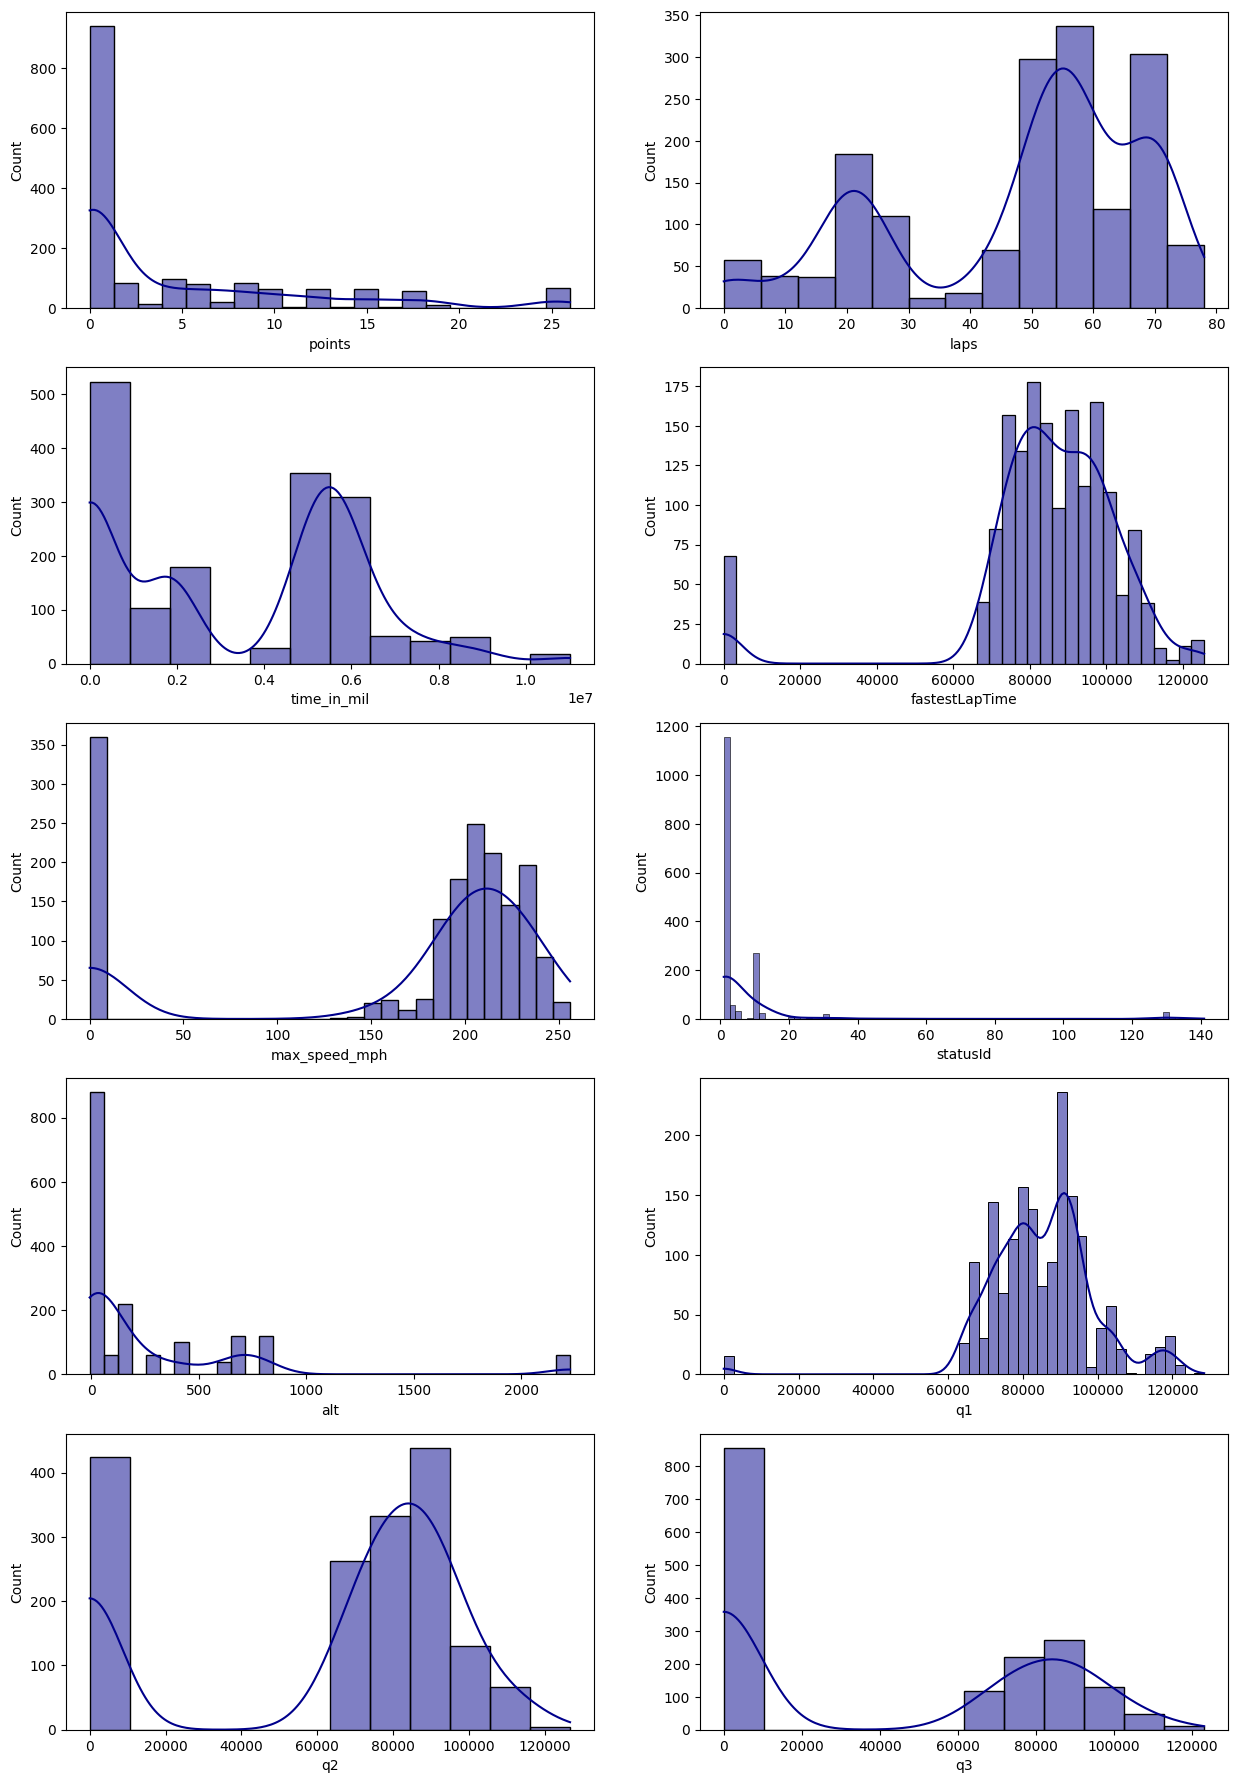

In [23]:
plt.figure(figsize=(15,50))
for i,j in zip(num_features,range(1,len(num_features)+1)):
    if i in ['start_position', 'finish_position']:
        continue
    plt.subplot(11,2,j)
    sns.histplot(selected_df[i] ,color='darkblue', kde=True)
plt.show()

As distribuições mostram padrões esperados num contexto de Fórmula 1. Valores iguais a zero não representam outliers, correspondem a pilotos que não completaram a corrida, não registaram tempos válidos ou não avançaram nas fases de qualificação.

**points:**

Distribuição altamente enviesada para zero e valores baixos. Isto é perfeito e esperado, a maioria dos pilotos não marca pontos na maioria das corridas
Esta variável tem relação direta com performance e pode ser uma feature útil, mas tem muita assimetria.

**times_in_mil:**
Parece multimodal, co
m vários picos. Isto faz sentido num dataset onde:
- diferentes pistas têm durações diferentes
- tempo total depende do número de voltas
- condições variadas

**fastestLapTime:**

A distribuição está concentrada entre cerca de 60k e 100k milissegundos, podemos verificar que a distribuição tem um outlier de tempo 0 o que significa que o piloto não completou uma volta para que possa-se registar o tempo.

**max_speed_mph:**

O histograma indicam grupos de diferentes tipos de pistas:
- circuitos urbanos mais lentos
- circuitos de alta velocidade como Monza

Isto é útil para clusters e para entender a performance em tipo de pista.

**statusId:**

Muito enviesado para valores baixos. É normal:
- statusId representa o estado final do carro (Finished, Accident, Engine, etc).
- A grande concentração deve ser "Finished".

**alt:**

Multimodal forte, pistas ao nível do mar vs pistas em altitude (México) já que a altitude afeta potência do motor.

**q1, q2, q3:**

As distribuições estão como esperado o forte outlier que tende para 0 singifica que o piloto não consegui definir um tempo para passar para a próxima sessão de qualificação.





In [24]:
data = selected_df['time_in_mil'] < 0.0
data.describe()

count      1659
unique        1
top       False
freq       1659
Name: time_in_mil, dtype: object

In [25]:
data = selected_df['fastestLapTime'] <0.0
data.describe()

count      1659
unique        1
top       False
freq       1659
Name: fastestLapTime, dtype: object

## Análise Bivariada

A análise bivariada examina as relações entre pares de variáveis para identificar padrões de associação, dependência ou correlação. Nesta secção, utilizamos matrizes de correlação e visualizações como heatmaps para explorar como diferentes métricas de desempenho se relacionam entre si e com características dos pilotos, construtores e circuitos. O objectivo é detectar variáveis redundantes, confirmar relações esperadas (como posição de qualificação vs pontos) e descobrir associações inesperadas que possam informar a engenharia de features ou a interpretação dos clusters.

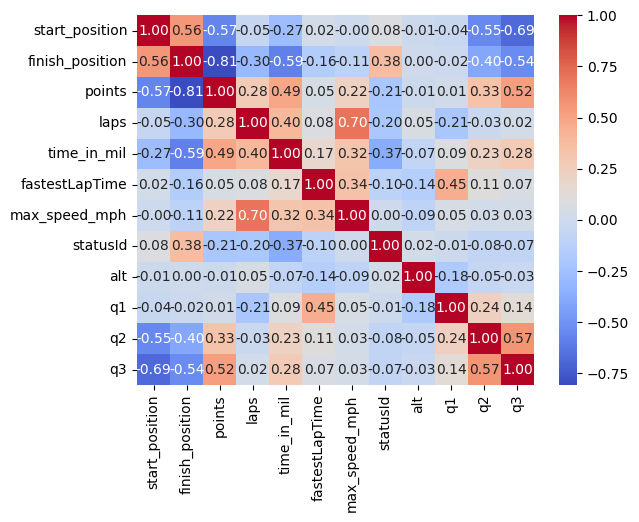

In [26]:
sns.heatmap(selected_df[num_features].corr(), annot = True, fmt = ".2f", cmap='coolwarm')
plt.show()

Analisando o heatmap de correlação, podemos verificar que certas variáveis apresentam correlações significativas:

- **start_position vs finish_position**: Estas variáveis apresentam forte correlação. Para capturar melhor a performance do piloto, criamos uma nova feature `position_delta` (start_position - finish_position) que representa o ganho ou perda de posições durante a corrida.

- **time_in_mil vs points**: Apesar da correlação elevada, optamos por manter ambas as colunas, pois cada uma fornece informação complementar sobre o desempenho dos pilotos. O tempo total reflete a execução completa da corrida, enquanto os pontos representam o resultado final.

- **q3 vs points**: Existe correlação significativa, uma vez que pilotos que qualificam no top 10 (Q3) tendem a manter posições competitivas até ao final da corrida. No entanto, mantemos ambas as variáveis pois contêm informações distintas relevantes para o modelo: qualificação representa performance em condições ideais, enquanto pontos refletem o resultado da corrida completa.

- **q1 vs fastestLapTime**: A correlação é esperada, já que na qualificação as equipas extraem o máximo desempenho dos carros em condições de pista limpa e sem tráfego. Nas corridas, com 20 pilotos simultaneamente na pista, as condições são diferentes. Ambas as métricas são mantidas por representarem contextos distintos de performance.

- **max_speed_mph vs laps**: Apesar da correlação observada, estas variáveis capturam aspectos diferentes do desempenho e características do circuito, sendo mantidas na análise.

Em suma, optamos por uma abordagem conservadora na eliminação de features, preservando variáveis que, apesar de correlacionadas, podem fornecer informação complementar para a identificação de padrões no clustering.

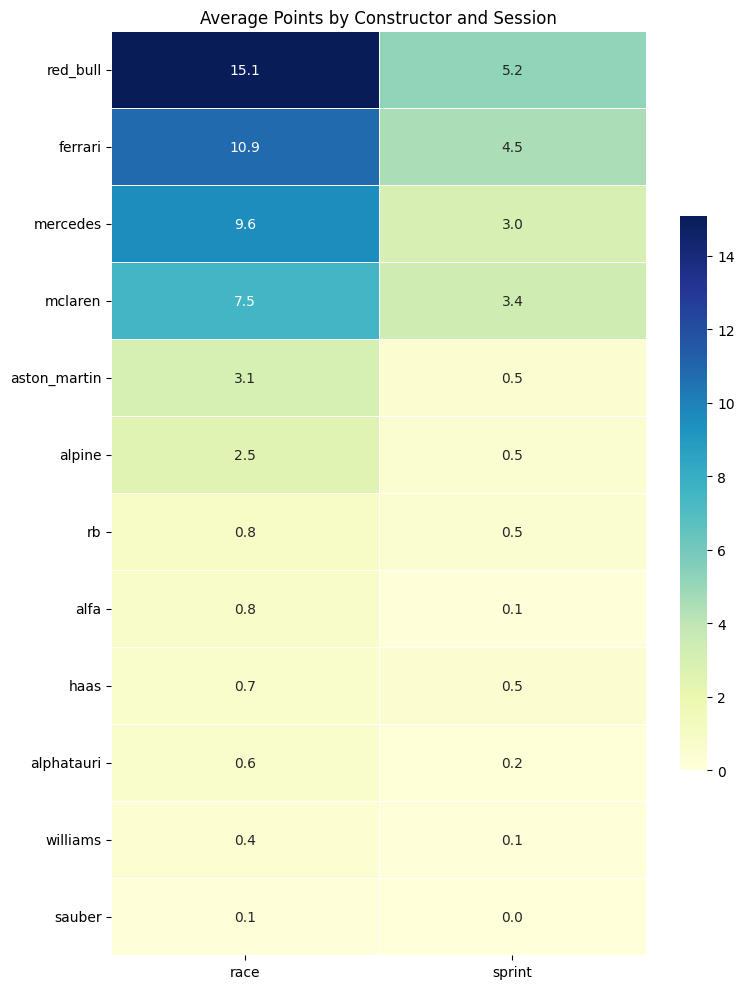

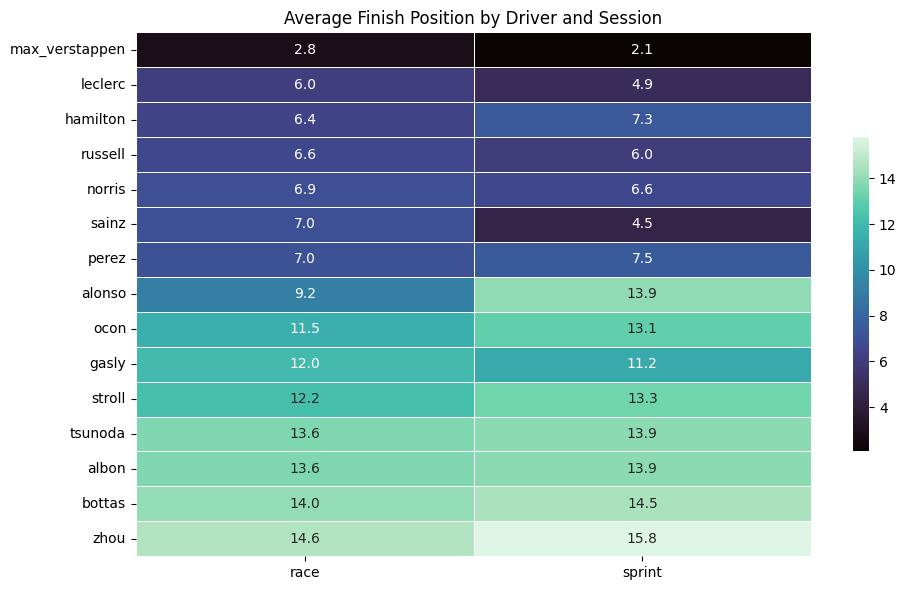

In [27]:
# Mean points by constructor/session heatmap
points_by_constructor = (
    selected_df.pivot_table(values="points", index="constructorRef", columns="session_type", aggfunc="mean")
    .sort_values("race", ascending=False)
)
plt.figure(figsize=(8, 10))
sns.heatmap(points_by_constructor, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Average Points by Constructor and Session")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Mean finish position by driver/session (top 15 drivers by race count)
top_drivers = (
    selected_df[selected_df["session_type"] == "race"]
    .groupby("driverRef")
    .size()
    .nlargest(15)
    .index
)
finish_by_driver = (
    selected_df[selected_df["driverRef"].isin(top_drivers)]
    .pivot_table(values="finish_position", index="driverRef", columns="session_type", aggfunc="mean")
    .sort_values("race", ascending=True)
)

plt.figure(figsize=(10, 6))
sns.heatmap(finish_by_driver, annot=True, fmt=".1f", cmap="mako", linewidths=0.5, cbar_kws={"shrink": 0.6})
plt.title("Average Finish Position by Driver and Session")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Feature Engineering

Nesta secção, são criadas novas variáveis derivadas dos dados existentes para capturar informações mais relevantes sobre o desempenho dos pilotos:

### Novas Features Criadas:

**position_delta:**
- Calculada como `start_position - finish_position`
- Representa o ganho ou perda de posições durante a corrida
- Valores positivos indicam que o piloto ganhou posições; valores negativos indicam perda de posições
- Substitui as variáveis originais de posição inicial e final, reduzindo correlação e capturando melhor a performance relativa

**pace:**
- Calculada como `time_in_mil / laps`
- Representa o tempo médio por volta em milissegundos
- Permite comparar a consistência e velocidade média dos pilotos independentemente do número de voltas completadas
- Útil para normalizar o desempenho entre diferentes circuitos e condições de corrida

**age:**
- Calculada a partir da data de nascimento do piloto (`dob`) e da data da corrida
- Representa a idade do piloto no momento de cada corrida
- Permite analisar se a idade influencia padrões de desempenho e identificar perfis etários nos clusters

**One-Hot Encoding e Label Encoding:**

- **session_type**: Aplicado One-Hot Encoding para converter a variável categórica (race/sprint) em formato binário. A primeira categoria é eliminada (`drop_first=True`) para evitar multicolinearidade.

- **nationality**: Aplicado Label Encoding para transformar as nacionalidades dos pilotos em valores numéricos. Esta abordagem é adequada pois permite ao modelo de clustering considerar a origem dos pilotos sem criar dimensionalidade excessiva.

- **Variáveis categóricas textuais**: As colunas de referência (driverRef, constructorRef, circuitRef) são mantidas no dataset para contextualização e interpretação dos resultados, sendo posicionadas no final do dataframe após as variáveis numéricas.

Estas transformações visam reduzir a dimensionalidade, eliminar redundâncias e criar métricas mais interpretáveis que capturem melhor o desempenho real dos pilotos para aplicação no modelo de clustering.


In [28]:
selected_df = selected_df.copy()
selected_df['position_delta'] = selected_df['start_position'] - selected_df['finish_position']
selected_df = selected_df.drop(columns=['start_position', 'finish_position'])
selected_df.head()

,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,session_type,driverRef,nationality,dob,constructorRef,circuitRef,alt,q1,q2,q3,position_delta
0,1074,26.0,57,5853584.0,94570,206.018,1,race,leclerc,Monegasque,1997-10-16,ferrari,bahrain,7,91471,90932,90558,0
1,1074,18.0,57,5859182.0,95740,203.501,1,race,sainz,Spanish,1994-09-01,ferrari,bahrain,7,91567,90787,90687,1
2,1074,15.0,57,5863259.0,96228,202.469,1,race,hamilton,British,1985-01-07,mercedes,bahrain,7,92285,91048,91238,2
3,1074,12.0,57,5864795.0,96302,202.313,1,race,russell,British,1998-02-15,mercedes,bahrain,7,92269,91252,92216,5
4,1074,10.0,57,5868338.0,96623,201.641,1,race,kevin_magnussen,Danish,1992-10-05,haas,bahrain,7,91955,91461,91808,2


In [29]:
selected_df['position_delta'].describe()

count    1659.000000
mean       -0.572634
std         5.430113
min       -20.000000
25%        -2.000000
50%         0.000000
75%         2.000000
max        16.000000
Name: position_delta, dtype: float64

In [30]:
selected_df = selected_df.copy()
selected_df['pace'] = selected_df['time_in_mil'] // selected_df['laps']

In [31]:
selected_df.head()

,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,session_type,driverRef,nationality,dob,constructorRef,circuitRef,alt,q1,q2,q3,position_delta,pace
0,1074,26.0,57,5853584.0,94570,206.018,1,race,leclerc,Monegasque,1997-10-16,ferrari,bahrain,7,91471,90932,90558,0,102694.0
1,1074,18.0,57,5859182.0,95740,203.501,1,race,sainz,Spanish,1994-09-01,ferrari,bahrain,7,91567,90787,90687,1,102792.0
2,1074,15.0,57,5863259.0,96228,202.469,1,race,hamilton,British,1985-01-07,mercedes,bahrain,7,92285,91048,91238,2,102864.0
3,1074,12.0,57,5864795.0,96302,202.313,1,race,russell,British,1998-02-15,mercedes,bahrain,7,92269,91252,92216,5,102891.0
4,1074,10.0,57,5868338.0,96623,201.641,1,race,kevin_magnussen,Danish,1992-10-05,haas,bahrain,7,91955,91461,91808,2,102953.0


In [32]:
selected_df['pace'].describe()

count      1618.000000
mean      71654.100124
std       57764.972558
min           0.000000
25%           0.000000
50%       86221.500000
75%      102424.500000
max      393289.000000
Name: pace, dtype: float64

In [33]:
race_dates = races_2024.set_index('raceId')['date']

selected_df['age'] = (
    (
        pd.to_datetime(selected_df['raceId'].map(race_dates), errors='coerce')
        - pd.to_datetime(selected_df['dob'], errors='coerce')
    )
    .dt.days.floordiv(365)
).astype('Int64')

selected_df[['driverRef', 'age']].head()
selected_df = selected_df.drop(columns=['dob'])

In [34]:
selected_df['age'].describe()

count       1659.0
mean     28.350211
std       5.532529
min           18.0
25%           24.0
50%           27.0
75%           33.0
max           43.0
Name: age, dtype: Float64

In [35]:
selected_df.describe().T

,count,mean,std,min,25%,50%,75%,max
raceId,1659.0,1110.55877,20.622593,1074.0,1093.0,1112.0,1128.0,1144.0
points,1659.0,4.500904,6.772663,0.0,0.0,0.0,8.0,26.0
laps,1659.0,48.431585,20.330546,0.0,28.0,55.0,64.0,78.0
time_in_mil,1659.0,3369674.658831,2858888.482914,0.0,0.0,4534875.0,5656050.5,11012095.0
fastestLapTime,1659.0,84985.207354,21198.159699,0.0,77504.0,86361.0,97106.0,125585.0
max_speed_mph,1659.0,164.818562,88.681348,0.0,166.9465,203.52,221.979,256.1
statusId,1659.0,7.927667,22.077221,1.0,1.0,1.0,6.0,141.0
alt,1659.0,267.154913,460.831152,-7.0,7.0,45.0,401.0,2227.0
q1,1659.0,85246.103074,14748.787102,0.0,77306.5,85711.0,93010.0,128510.0
q2,1659.0,63301.185654,38569.473596,0.0,0.0,79119.0,89723.5,126688.0


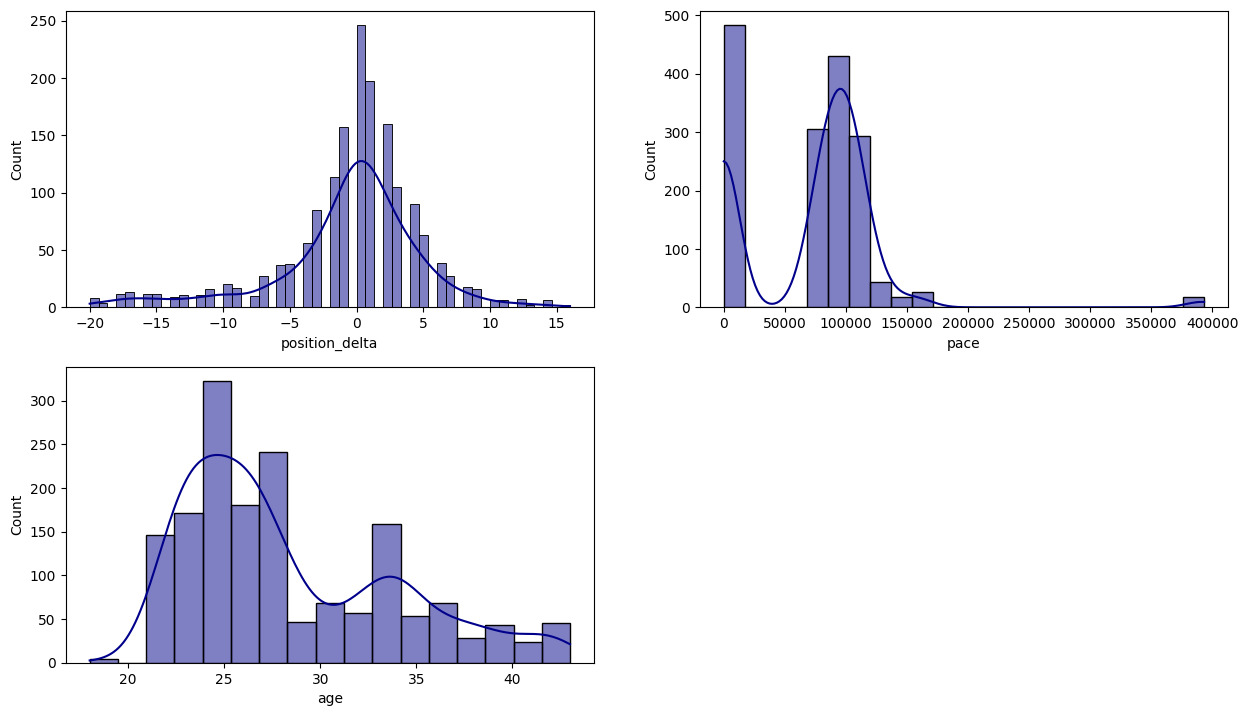

In [36]:
feature_r = ['position_delta', 'pace', 'age']
plt.figure(figsize=(15,50))
for i,j in zip(feature_r,range(1,len(feature_r)+1)):
    plt.subplot(11,2,j)
    sns.histplot(selected_df[i] ,color='darkblue', kde=True)
plt.show()

### Análise das Novas Features

**position_delta:**

A distribuição é aproximadamente normal e centrada em zero, o que indica que a maioria dos pilotos mantém a sua posição inicial ou sofre alterações ligeiras. As caudas mais pronunciadas no lado negativo refletem perdas significativas de posições, tipicamente causadas por acidentes, falhas mecânicas ou estratégias menos eficazes. Esta variável está adequadamente limpa e representa de forma eficaz a variação de performance entre pilotos durante a corrida.

**pace:**

A distribuição apresenta múltiplos picos e alguns valores extremos. Os valores muito baixos ou próximos de zero correspondem a DNFs (Did Not Finish) ou registos de tempo inválidos. Os valores extremamente elevados indicam erros de registo ou voltas incompletas. A porção central da distribuição, situada entre aproximadamente 80.000 e 120.000 ms, representa o pace real e consistente dos pilotos em condições normais de corrida.

**age:**

A distribuição revela dois grupos etários principais: pilotos jovens (entre 23 e 27 anos) e pilotos mais experientes (acima dos 30 anos). Esta distribuição é natural e coerente com a realidade da Fórmula 1.

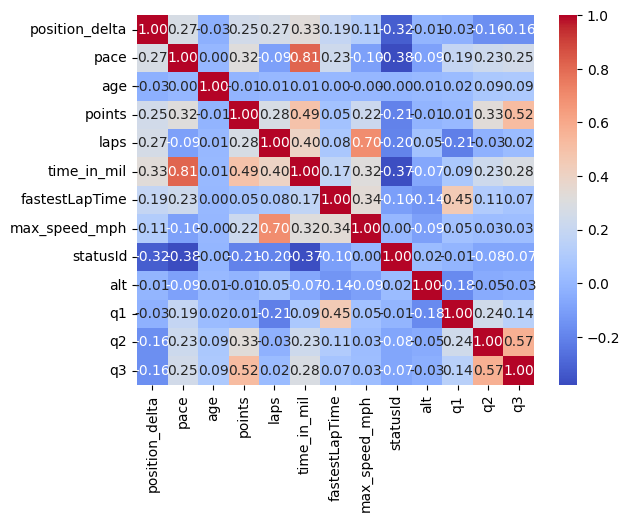

In [37]:
feature_all = ['position_delta', 'pace', 'age'] + num_features[2:]
sns.heatmap(selected_df[feature_all].corr(), annot = True, fmt = ".2f", cmap='coolwarm')
plt.show()

In [38]:
selected_df = pd.get_dummies(selected_df, columns=['session_type'], drop_first=True)

In [39]:
encoder = LabelEncoder()
selected_df["nationality"] = encoder.fit_transform(selected_df["nationality"])
selected_df

,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,driverRef,nationality,constructorRef,circuitRef,alt,q1,q2,q3,position_delta,pace,age,session_type_sprint
0,1074,26.0,57,5853584.0,94570,206.018,1,leclerc,13,ferrari,bahrain,7,91471,90932,90558,0,102694.0,24,False
1,1074,18.0,57,5859182.0,95740,203.501,1,sainz,15,ferrari,bahrain,7,91567,90787,90687,1,102792.0,27,False
2,1074,15.0,57,5863259.0,96228,202.469,1,hamilton,3,mercedes,bahrain,7,92285,91048,91238,2,102864.0,37,False
3,1074,12.0,57,5864795.0,96302,202.313,1,russell,3,mercedes,bahrain,7,92269,91252,92216,5,102891.0,24,False
4,1074,10.0,57,5868338.0,96623,201.641,1,kevin_magnussen,6,haas,bahrain,7,91955,91461,91808,2,102953.0,29,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,1143,0.0,19,1657366.0,85762,0.000,1,lawson,14,rb,losail,12,82411,0,0,-6,87229.0,22,True
1655,1143,0.0,19,1658112.0,85838,0.000,1,tsunoda,11,rb,losail,12,82364,81771,0,-1,87269.0,24,True
1656,1143,0.0,19,1658649.0,85599,0.000,1,colapinto,1,williams,losail,12,82594,0,0,-18,87297.0,21,True
1657,1143,0.0,19,1694446.0,85051,0.000,1,zhou,5,sauber,losail,12,82103,81501,0,-1,89181.0,25,True


In [40]:
object_cols = selected_df.select_dtypes(include=['object']).columns
num_features = selected_df.select_dtypes(include=['int64', 'float64', 'Int64', 'bool']).columns

ordered_cols = list(num_features) + list(object_cols)
selected_df = selected_df.loc[:, ordered_cols]

In [41]:
selected_df.isna().sum()

raceId                  0
points                  0
laps                    0
time_in_mil             0
fastestLapTime          0
max_speed_mph           0
statusId                0
nationality             0
alt                     0
q1                      0
q2                      0
q3                      0
position_delta          0
pace                   41
age                     0
session_type_sprint     0
driverRef               0
constructorRef          0
circuitRef              0
dtype: int64

In [42]:
pace_mean = selected_df['pace'].mean(skipna=True)
selected_df['pace'] = selected_df['pace'].fillna(pace_mean)

In [43]:
selected_df

,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,nationality,alt,q1,q2,q3,position_delta,pace,age,session_type_sprint,driverRef,constructorRef,circuitRef
0,1074,26.0,57,5853584.0,94570,206.018,1,13,7,91471,90932,90558,0,102694.0,24,False,leclerc,ferrari,bahrain
1,1074,18.0,57,5859182.0,95740,203.501,1,15,7,91567,90787,90687,1,102792.0,27,False,sainz,ferrari,bahrain
2,1074,15.0,57,5863259.0,96228,202.469,1,3,7,92285,91048,91238,2,102864.0,37,False,hamilton,mercedes,bahrain
3,1074,12.0,57,5864795.0,96302,202.313,1,3,7,92269,91252,92216,5,102891.0,24,False,russell,mercedes,bahrain
4,1074,10.0,57,5868338.0,96623,201.641,1,6,7,91955,91461,91808,2,102953.0,29,False,kevin_magnussen,haas,bahrain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1654,1143,0.0,19,1657366.0,85762,0.000,1,14,12,82411,0,0,-6,87229.0,22,True,lawson,rb,losail
1655,1143,0.0,19,1658112.0,85838,0.000,1,11,12,82364,81771,0,-1,87269.0,24,True,tsunoda,rb,losail
1656,1143,0.0,19,1658649.0,85599,0.000,1,1,12,82594,0,0,-18,87297.0,21,True,colapinto,williams,losail
1657,1143,0.0,19,1694446.0,85051,0.000,1,5,12,82103,81501,0,-1,89181.0,25,True,zhou,sauber,losail


## Exportar Dataset Processado

Após a conclusão de todas as etapas de limpeza, transformação e engenharia de features, o dataset processado está pronto para ser exportado e utilizado na fase de modelação de clustering.

O ficheiro será guardado em formato CSV no diretório `data/` com o nome `f1_processed_clustering.csv`, contendo todas as variáveis numéricas e categóricas codificadas que serão utilizadas como input para o algoritmo K-Means.

In [44]:
path = "data/f1_processed_clustering.csv"

os.makedirs("data", exist_ok=True)

selected_df.to_csv(path, index=False)

print(f"Dataset processado guardado em {path}")

Dataset processado guardado em data/f1_processed_clustering.csv


## Conclusão

Neste notebook realizou-se uma análise exploratória completa do dataset de Fórmula 1 (2022-2024), com foco na preparação dos dados para clustering. As principais etapas incluíram:

1. **Carregamento e Filtragem:** Selecionámos dados a partir de 2022, coincidindo com a mudança de regulamentos técnicos que alterou significativamente o comportamento dos carros.

2. **Integração de Dados:** Consolidámos informações de múltiplas fontes (corridas, sprints, qualificações, pilotos, construtores e circuitos) num único dataframe estruturado.

3. **Tratamento de Dados:** Convertemos variáveis para tipos numéricos adequados, padronizámos formatos de tempo e tratámos valores ausentes de forma contextualizada.

4. **Análise Univariada e Bivariada:** Identificámos padrões de distribuição esperados, correlações relevantes entre variáveis e validámos a integridade dos dados.

5. **Engenharia de Features:** Criámos novas variáveis derivadas (`position_delta`, `pace`, `age`) que capturam melhor o desempenho dos pilotos, reduzindo redundâncias e aumentando a interpretabilidade.

6. **Codificação de Variáveis Categóricas:** Aplicámos One-Hot Encoding e Label Encoding para preparar o dataset para algoritmos de machine learning.

O dataset final, exportado como `f1_processed_clustering.csv`, contém variáveis numéricas limpas e normalizadas, prontas para alimentar o modelo K-Means. Este processo de EDA garante que os dados estão estruturados, consistentes e otimizados para a identificação de padrões de desempenho e perfis de pilotos através de técnicas de clustering não supervisionado.